In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
from statsmodels.tsa.seasonal import seasonal_decompose

In [25]:
df = pd.read_csv('Tesla.csv')
df.head()

,Date,Open,High,Low,Close,Volume,Adj Close
0,6/29/2010,19.000000,25.00,17.540001,23.889999,18766300,23.889999
1,6/30/2010,25.790001,30.42,23.299999,23.830000,17187100,23.830000
2,7/1/2010,25.000000,25.92,20.270000,21.959999,8218800,21.959999
3,7/2/2010,23.000000,23.10,18.709999,19.200001,5139800,19.200001
4,7/6/2010,20.000000,20.00,15.830000,16.110001,6866900,16.110001


In [26]:
# Check for missing values
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Volume,0
Adj Close,0


In [27]:
print("Shape:", df.shape)

Shape: (1692, 7)


In [28]:
df.describe()

,Open,High,Low,Close,Volume,Adj Close
count,1692.000000,1692.000000,1692.000000,1692.000000,1.692000e+03,1692.000000
mean,132.441572,134.769698,129.996223,132.428658,4.270741e+06,132.428658
std,94.309923,95.694914,92.855227,94.313187,4.295971e+06,94.313187
min,16.139999,16.629999,14.980000,15.800000,1.185000e+05,15.800000
25%,30.000000,30.650000,29.215000,29.884999,1.194350e+06,29.884999
50%,156.334999,162.370002,153.150002,158.160004,3.180700e+06,158.160004
75%,220.557495,224.099999,217.119999,220.022503,5.662100e+06,220.022503
max,287.670013,291.420013,280.399994,286.040009,3.716390e+07,286.040009


This complete dataset of 1,692 records reveals high variability in Tesla stock prices, ranging from 15 to 286 with a 132 average. Volumes also fluctuate significantly.

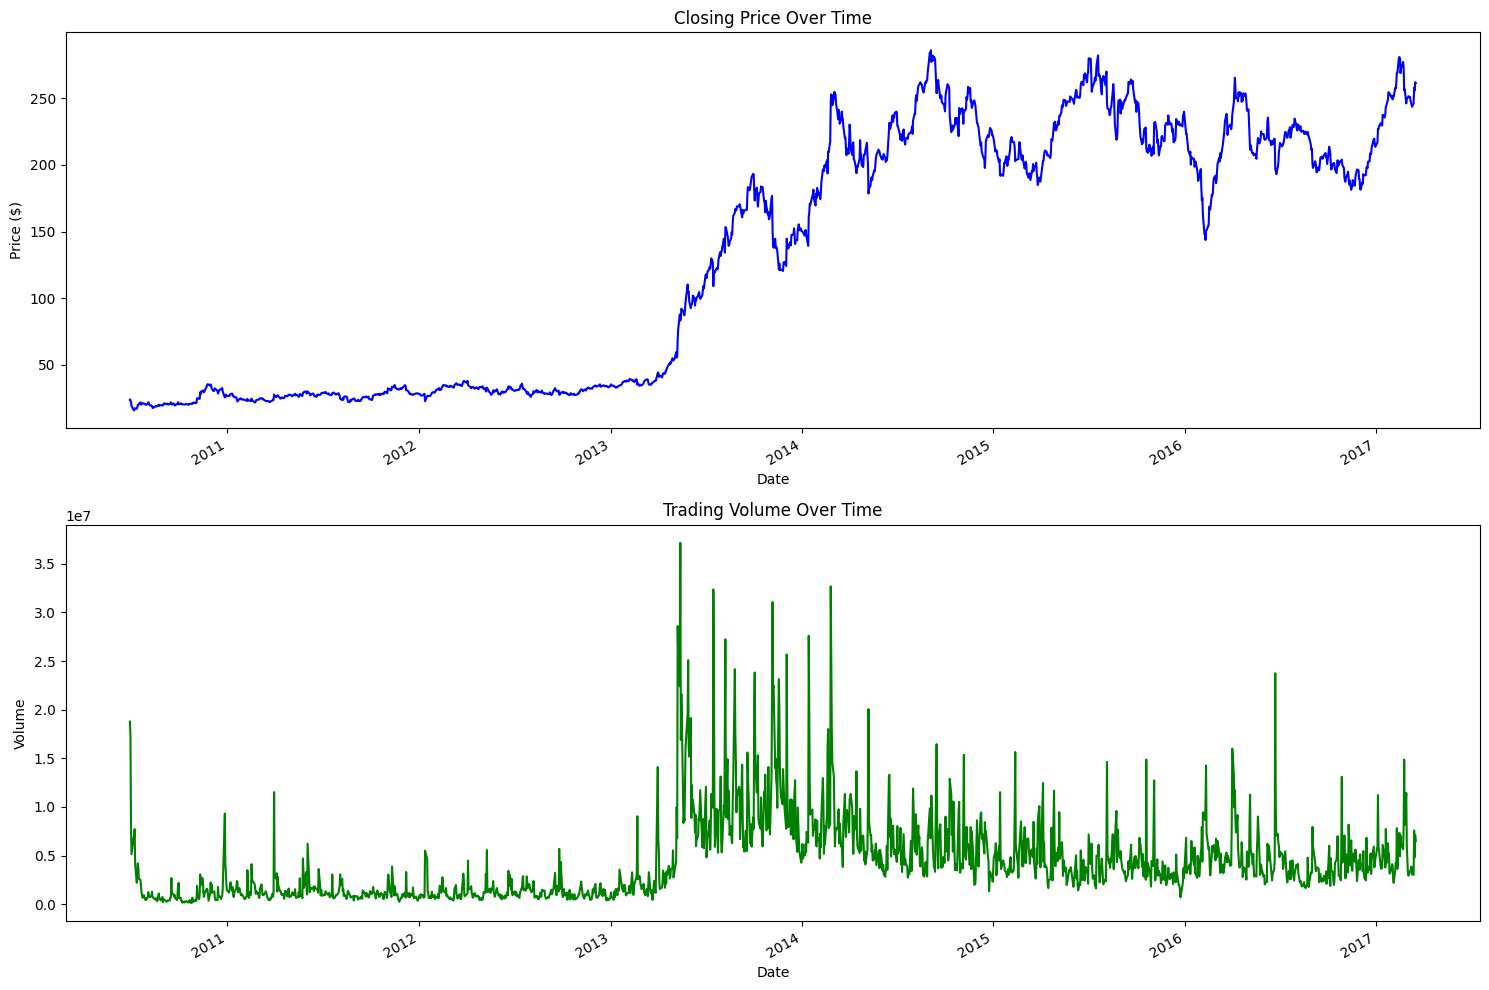

In [29]:
# Convert the 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Set the date as the index of the dataframe for plotting
df.set_index('Date', inplace=True)

# Create a figure and a set of subplots
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(15, 10))

# Plot the closing price over time
df['Close'].plot(ax=ax[0], color='blue')
ax[0].set_title('Closing Price Over Time')
ax[0].set_ylabel('Price ($)')

# Plot the trading volume over time
df['Volume'].plot(ax=ax[1], color='green')
ax[1].set_title('Trading Volume Over Time')
ax[1].set_ylabel('Volume')

# Improve layout
plt.tight_layout()
plt.show()


These plots visualize the historical market performance of Tesla. The closing price displays an overall upward trend despite typical stock volatility and occasional declines. Meanwhile, trading volume spikes often align with significant company events. Next, we will use Facebook Prophet for time series forecasting to analyze key trends, seasonality, and market holidays.

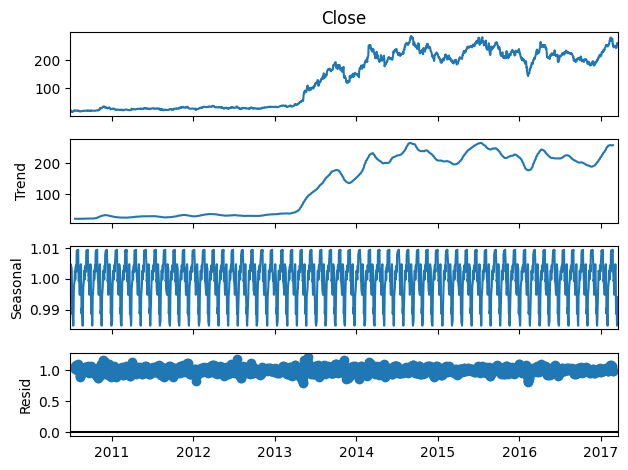

In [30]:
# Seasonality Analysis
decomposition = seasonal_decompose(df['Close'], model='multiplicative', period=30)
fig = decomposition.plot()
plt.show()

Tesla stock shows a general upward trend with minor monthly seasonal patterns. Increasing residuals indicate growing unpredictability over time. Next, we will perform a volatility analysis to measure how dramatically these returns fluctuate and assess risk.

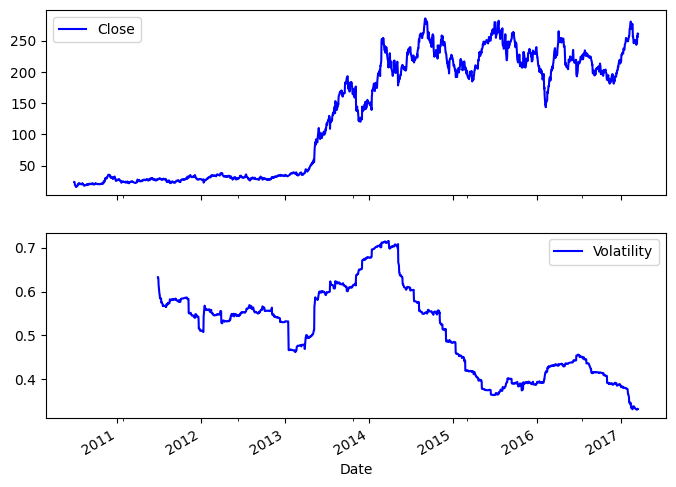

In [31]:
# Volatility Analysis
df['Return'] = df['Close'].pct_change()
df['Volatility'] = df['Return'].rolling(window=252).std() * np.sqrt(252)
df[['Close', 'Volatility']].plot(subplots=True, color='blue', figsize=(8, 6))
plt.show()

Tesla stock shows an upward trend alongside sharp volatility peaks, indicating high risk and dramatic price fluctuations. Next, we will plot ten and fifty day moving averages to smooth out market noise and identify short and long term trend directions very clearly.

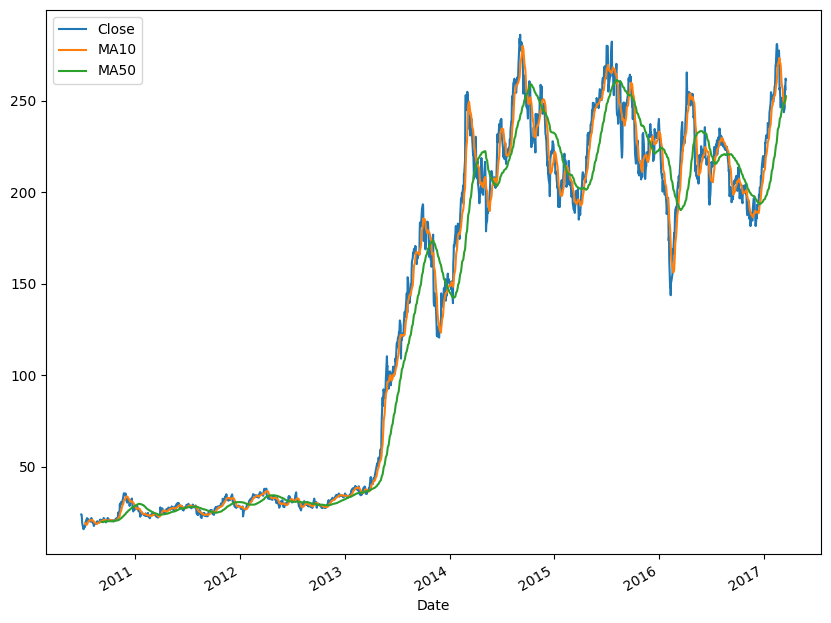

In [32]:
# Moving Average Analysis
df['MA10'] = df['Close'].rolling(window=10).mean()
df['MA50'] = df['Close'].rolling(window=50).mean()
df[['Close','MA10','MA50']].plot(label='Tesla', figsize=(10,8))
plt.show()

Moving Averages
Tesla's stock generally trends upward. Short-term and long-term trends are revealed by the 10-day and 50-day moving averages. Traders watch crossovers: 10-day crossing above 50-day signals bullish buying, while dropping below is bearish. Next, we analyze daily returns.

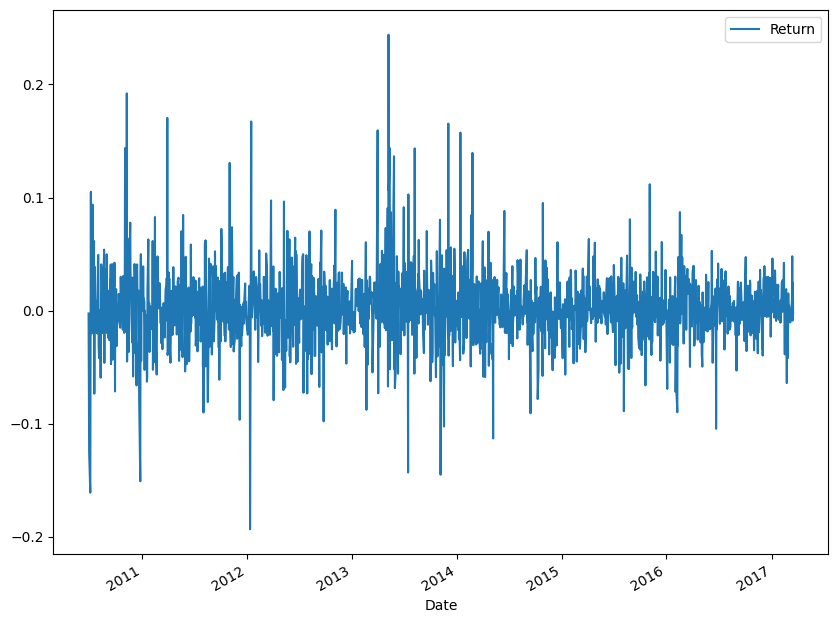

In [33]:

# Return Analysis
df['Return'] = df['Close'].pct_change()
df[['Return']].plot(label='Return', figsize=(10,8))
plt.show()

The return analysis chart displays daily percentage changes fluctuating near zero, showing a mix of stock gains and losses. Swing magnitudes reveal volatility levels. Extreme spikes indicate significant price shifts often tied to major company events or news. Positive returns mean increases, and negative returns mean daily decreases.

To forecast with Prophet, we must format the dataframe into two columns: "ds" for the datestamps and "y" for our target prediction values, the Close price.

In [34]:
# Prepare the data for Prophet
prophet_df = df.reset_index()[['Date', 'Close']]
prophet_df.rename(columns={'Date': 'ds', 'Close': 'y'}, inplace=True)

prophet_df.head()


,ds,y
0,2010-06-29,23.889999
1,2010-06-30,23.830000
2,2010-07-01,21.959999
3,2010-07-02,19.200001
4,2010-07-06,16.110001


In [35]:
# Initialize the Prophet model
model = Prophet()

In [36]:
# Fit the model to the data
model.fit(prophet_df)

# Specify the number of days for predictions
future = model.make_future_dataframe(periods=365)

# Use the model to make predictions
forecast = model.predict(future)


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


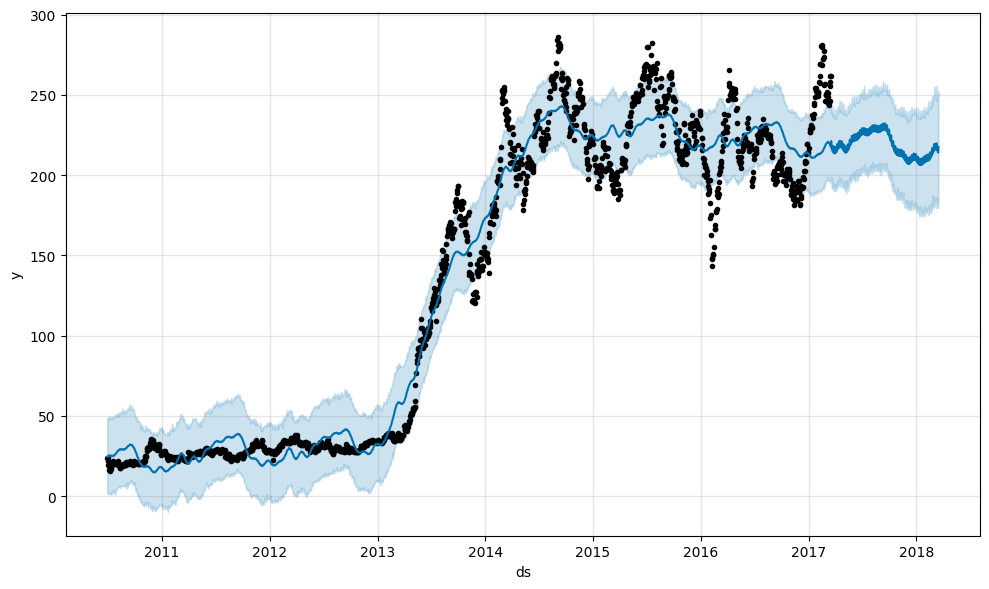

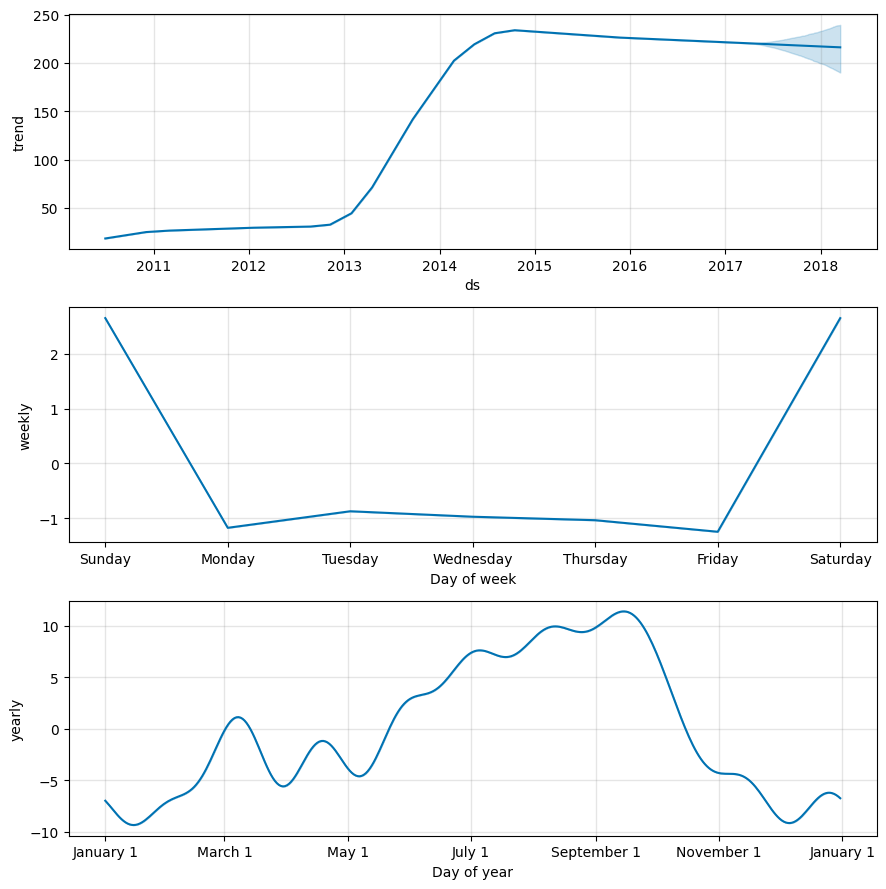

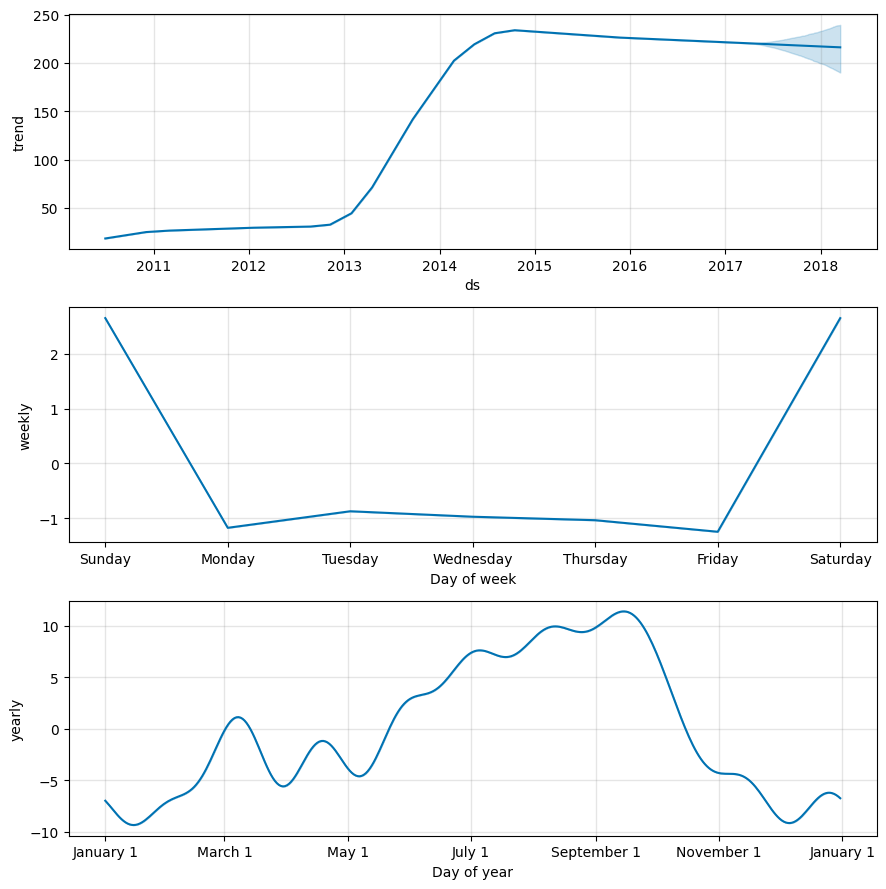

In [37]:
# Visualize the forecast
model.plot(forecast)
plt.show()

# If you want to see the components of the forecast, you can use:
model.plot_components(forecast)